In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# Upload the file
print("Please upload the Excel file (ai_model (3).xlsx):")
uploaded = files.upload()

# Read the Excel file
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name='Sheet1')

# Display basic information
print("Dataset Shape:", df.shape)

# Clean the data - replace 'Null' strings with NaN
df.replace('Null', np.nan, inplace=True)
df.replace('null', np.nan, inplace=True)

# Separate Dengue and Chikungunya patients
df_dengue = df[df['Disease Type'].str.contains('Dengue', case=False, na=False)].copy()
df_chik = df[df['Disease Type'].str.contains('Chikungunya', case=False, na=False)].copy()

total_dengue = len(df_dengue)
total_chik = len(df_chik)

print(f"\nTotal Patients: {len(df)}")
print(f"Dengue Patients: {total_dengue}")
print(f"Chikungunya Patients: {total_chik}")

Please upload the Excel file (ai_model (3).xlsx):


Saving ai_model (3).xlsx to ai_model (3).xlsx
Dataset Shape: (265, 48)

Total Patients: 265
Dengue Patients: 160
Chikungunya Patients: 105


1. WASTE MANAGEMENT INFRASTRUCTURE ANALYSIS
Using column: Waste management infrastructure (Garbage collection frequency, presence of open dumps)

Dengue Waste Management:
  No: 93 (58.1%)
  Yes: 67 (41.9%)

Chikungunya Waste Management:
  Yes: 87 (82.9%)
  No: 18 (17.1%)


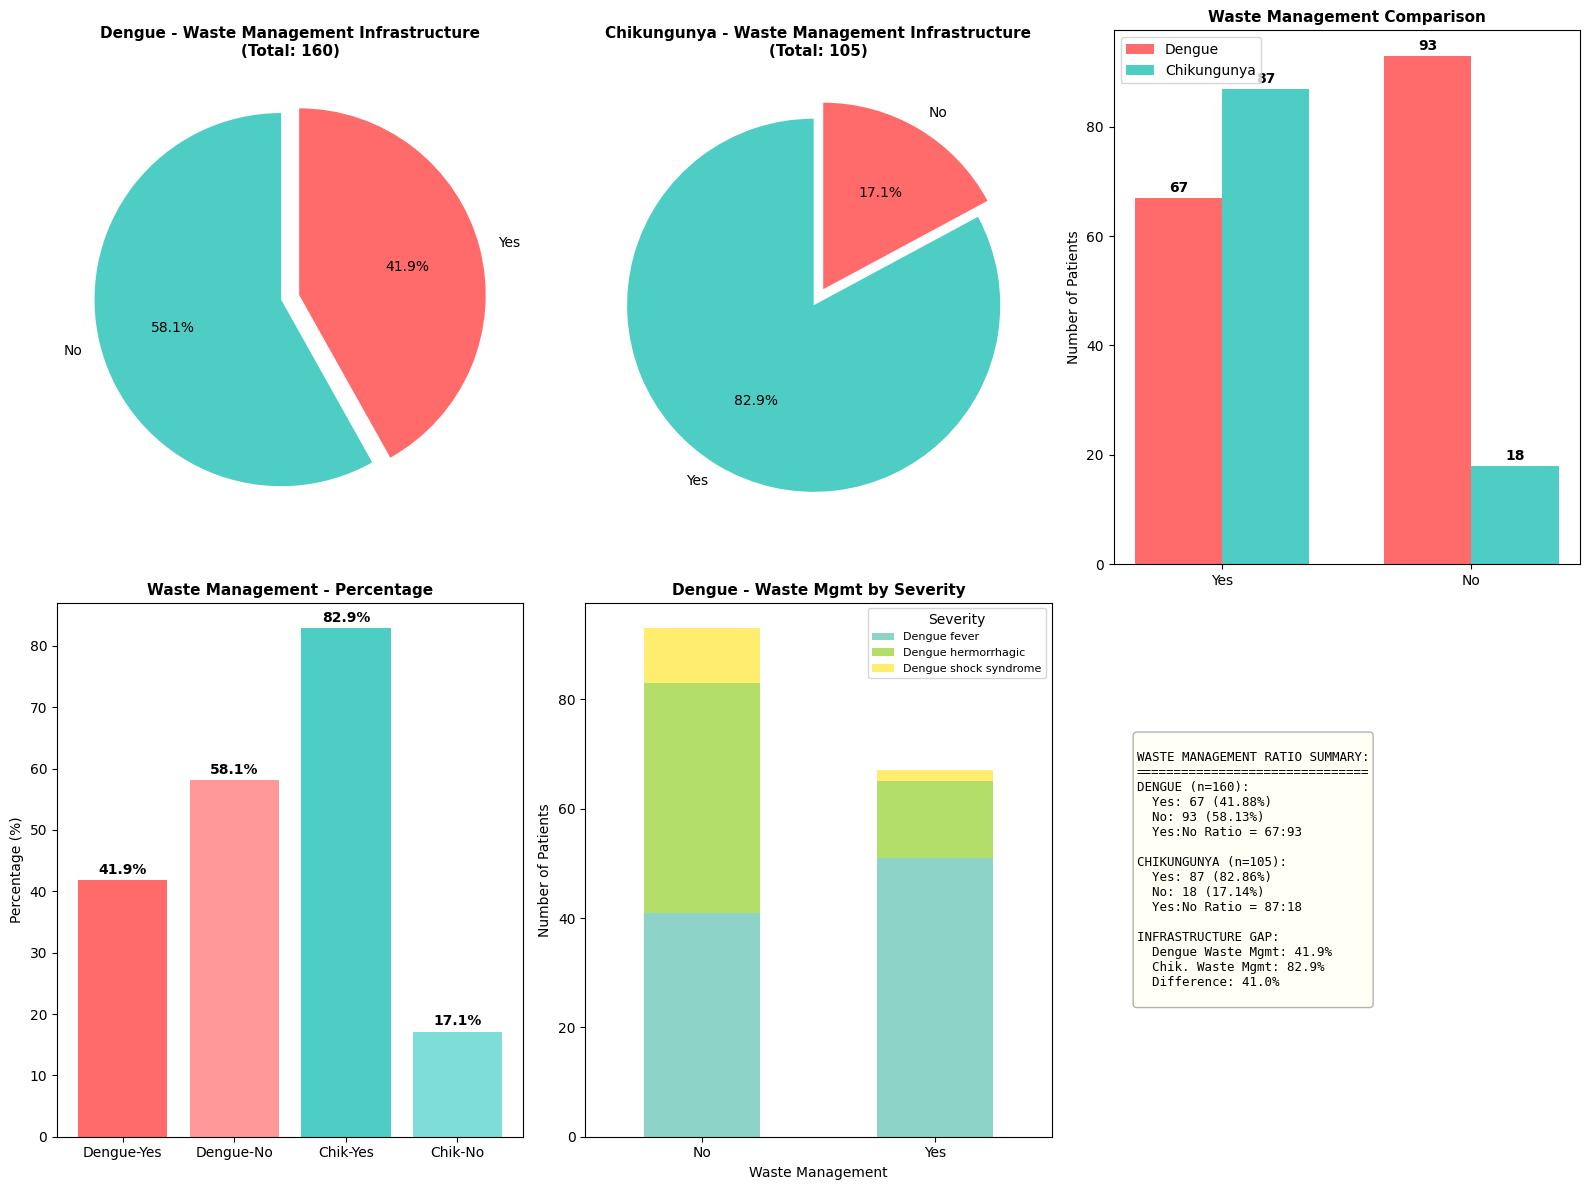

In [ ]:
# =============================================================================
# 1. WASTE MANAGEMENT INFRASTRUCTURE ANALYSIS
# =============================================================================

print("="*70)
print("1. WASTE MANAGEMENT INFRASTRUCTURE ANALYSIS")
print("="*70)

# Find waste management column
waste_col = None
for col in df.columns:
    if 'Waste' in col:
        waste_col = col
        break

print(f"Using column: {waste_col}")

# Convert to Yes/No for clarity
df_dengue['Waste_Mgmt'] = df_dengue[waste_col].apply(
    lambda x: 'Yes' if str(x).strip().lower() == 'yes' else 'No')
df_chik['Waste_Mgmt'] = df_chik[waste_col].apply(
    lambda x: 'Yes' if str(x).strip().lower() == 'yes' else 'No')

# Get counts
waste_dengue = df_dengue['Waste_Mgmt'].value_counts()
waste_chik = df_chik['Waste_Mgmt'].value_counts()

print(f"\nDengue Waste Management:")
for idx, val in waste_dengue.items():
    print(f"  {idx}: {val} ({val/total_dengue*100:.1f}%)")

print(f"\nChikungunya Waste Management:")
for idx, val in waste_chik.items():
    print(f"  {idx}: {val} ({val/total_chik*100:.1f}%)")

plt.figure(figsize=(16, 12))

# Subplot 1: Dengue Waste Management Pie
plt.subplot(2, 3, 1)
colors_waste = ['#4ECDC4', '#FF6B6B']
plt.pie(waste_dengue.values, labels=waste_dengue.index, autopct='%1.1f%%',
        colors=colors_waste[:len(waste_dengue)], startangle=90, explode=[0.05]*len(waste_dengue))
plt.title(f'Dengue - Waste Management Infrastructure\n(Total: {total_dengue})', fontsize=11, fontweight='bold')

# Subplot 2: Chikungunya Waste Management Pie
plt.subplot(2, 3, 2)
plt.pie(waste_chik.values, labels=waste_chik.index, autopct='%1.1f%%',
        colors=colors_waste[:len(waste_chik)], startangle=90, explode=[0.05]*len(waste_chik))
plt.title(f'Chikungunya - Waste Management Infrastructure\n(Total: {total_chik})', fontsize=11, fontweight='bold')

# Subplot 3: Waste Management Comparison Bar
plt.subplot(2, 3, 3)
categories = ['Yes', 'No']
dengue_vals = [waste_dengue.get('Yes', 0), waste_dengue.get('No', 0)]
chik_vals = [waste_chik.get('Yes', 0), waste_chik.get('No', 0)]

x = np.arange(len(categories))
width = 0.35
bars1 = plt.bar(x - width/2, dengue_vals, width, label='Dengue', color='#FF6B6B')
bars2 = plt.bar(x + width/2, chik_vals, width, label='Chikungunya', color='#4ECDC4')
plt.xticks(x, categories)
plt.title('Waste Management Comparison', fontsize=11, fontweight='bold')
plt.ylabel('Number of Patients')
plt.legend()

for bar, val in zip(bars1, dengue_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')
for bar, val in zip(bars2, chik_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')

# Subplot 4: Percentage Comparison
plt.subplot(2, 3, 4)
dengue_yes_pct = (waste_dengue.get('Yes', 0) / total_dengue) * 100
dengue_no_pct = (waste_dengue.get('No', 0) / total_dengue) * 100
chik_yes_pct = (waste_chik.get('Yes', 0) / total_chik) * 100
chik_no_pct = (waste_chik.get('No', 0) / total_chik) * 100

bars = plt.bar(['Dengue-Yes', 'Dengue-No', 'Chik-Yes', 'Chik-No'],
              [dengue_yes_pct, dengue_no_pct, chik_yes_pct, chik_no_pct],
              color=['#FF6B6B', '#FF9999', '#4ECDC4', '#7EDDD6'])
plt.title('Waste Management - Percentage', fontsize=11, fontweight='bold')
plt.ylabel('Percentage (%)')
for bar, pct in zip(bars, [dengue_yes_pct, dengue_no_pct, chik_yes_pct, chik_no_pct]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontweight='bold')

# Subplot 5: Waste Management by Severity (Dengue)
plt.subplot(2, 3, 5)
waste_severity = pd.crosstab(df_dengue['Waste_Mgmt'], df_dengue['Severity Classification'])
if len(waste_severity) > 0:
    waste_severity.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set3')
    plt.title('Dengue - Waste Mgmt by Severity', fontsize=11, fontweight='bold')
    plt.xlabel('Waste Management')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=0)
    plt.legend(title='Severity', fontsize=8)

# Subplot 6: Summary
plt.subplot(2, 3, 6)
plt.axis('off')
waste_summary = f"""
WASTE MANAGEMENT RATIO SUMMARY:
===============================
DENGUE (n={total_dengue}):
  Yes: {waste_dengue.get('Yes', 0)} ({dengue_yes_pct:.2f}%)
  No: {waste_dengue.get('No', 0)} ({dengue_no_pct:.2f}%)
  Yes:No Ratio = {waste_dengue.get('Yes', 0)}:{waste_dengue.get('No', 0)}

CHIKUNGUNYA (n={total_chik}):
  Yes: {waste_chik.get('Yes', 0)} ({chik_yes_pct:.2f}%)
  No: {waste_chik.get('No', 0)} ({chik_no_pct:.2f}%)
  Yes:No Ratio = {waste_chik.get('Yes', 0)}:{waste_chik.get('No', 0)}

INFRASTRUCTURE GAP:
  Dengue Waste Mgmt: {dengue_yes_pct:.1f}%
  Chik. Waste Mgmt: {chik_yes_pct:.1f}%
  Difference: {abs(dengue_yes_pct - chik_yes_pct):.1f}%
"""
plt.text(0.05, 0.5, waste_summary, fontsize=9, family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3),
         verticalalignment='center')

plt.tight_layout()
plt.show()


2. PROXIMITY TO WATER SOURCE ANALYSIS
Using column: Proximity to water source (River,lakes, drains)

Dengue - Proximity to Water Source:
  Yes: 91 (56.9%)
  No: 69 (43.1%)

Chikungunya - Proximity to Water Source:
  Yes: 53 (50.5%)
  No: 52 (49.5%)


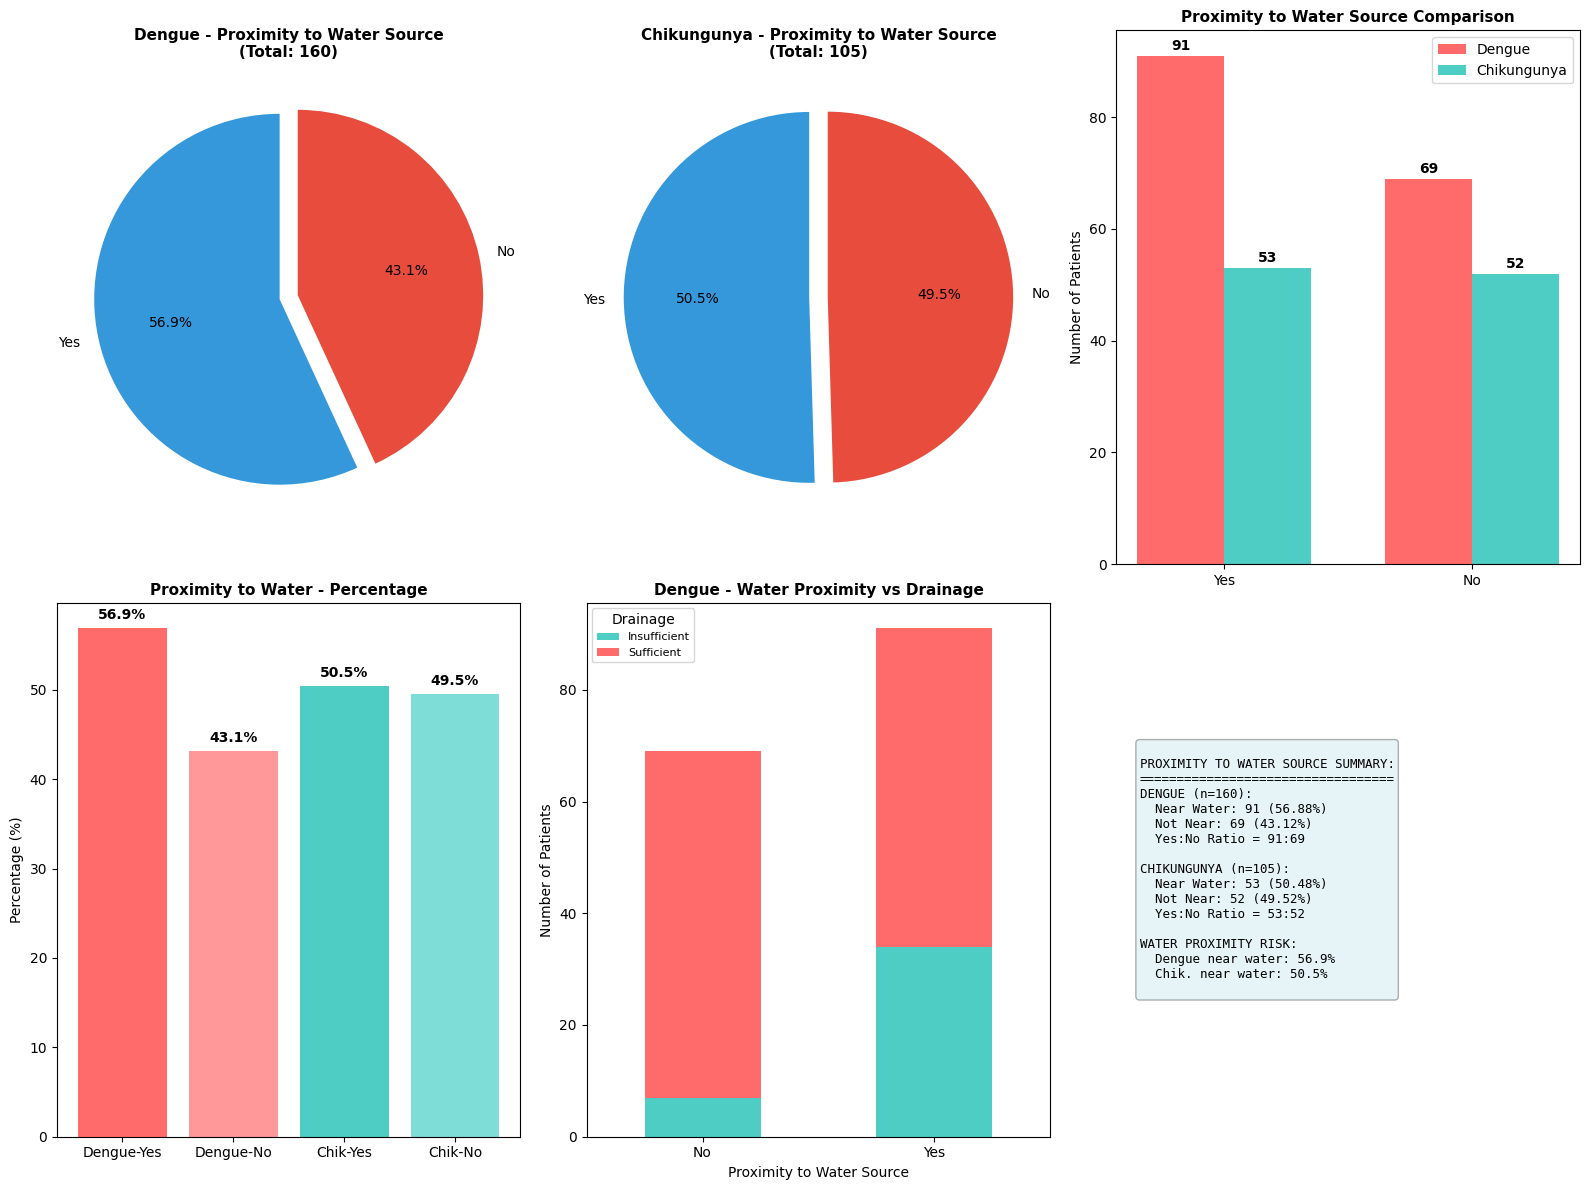

In [ ]:
# =============================================================================
# 2. PROXIMITY TO WATER SOURCE ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("2. PROXIMITY TO WATER SOURCE ANALYSIS")
print("="*70)

# Find proximity to water source column
water_source_col = None
for col in df.columns:
    if 'Proximity to water source' in col:
        water_source_col = col
        break

print(f"Using column: {water_source_col}")

# Convert to Yes/No
df_dengue['Water_Proximity'] = df_dengue[water_source_col].apply(
    lambda x: 'Yes' if str(x).strip().lower() == 'yes' else 'No')
df_chik['Water_Proximity'] = df_chik[water_source_col].apply(
    lambda x: 'Yes' if str(x).strip().lower() == 'yes' else 'No')

# Get counts
water_dengue = df_dengue['Water_Proximity'].value_counts()
water_chik = df_chik['Water_Proximity'].value_counts()

print(f"\nDengue - Proximity to Water Source:")
for idx, val in water_dengue.items():
    print(f"  {idx}: {val} ({val/total_dengue*100:.1f}%)")

print(f"\nChikungunya - Proximity to Water Source:")
for idx, val in water_chik.items():
    print(f"  {idx}: {val} ({val/total_chik*100:.1f}%)")

plt.figure(figsize=(16, 12))

# Subplot 1: Dengue Water Proximity Pie
plt.subplot(2, 3, 1)
colors_water = ['#3498DB', '#E74C3C']
plt.pie(water_dengue.values, labels=water_dengue.index, autopct='%1.1f%%',
        colors=colors_water[:len(water_dengue)], startangle=90, explode=[0.05]*len(water_dengue))
plt.title(f'Dengue - Proximity to Water Source\n(Total: {total_dengue})', fontsize=11, fontweight='bold')

# Subplot 2: Chikungunya Water Proximity Pie
plt.subplot(2, 3, 2)
plt.pie(water_chik.values, labels=water_chik.index, autopct='%1.1f%%',
        colors=colors_water[:len(water_chik)], startangle=90, explode=[0.05]*len(water_chik))
plt.title(f'Chikungunya - Proximity to Water Source\n(Total: {total_chik})', fontsize=11, fontweight='bold')

# Subplot 3: Water Proximity Comparison Bar
plt.subplot(2, 3, 3)
categories = ['Yes', 'No']
dengue_water_vals = [water_dengue.get('Yes', 0), water_dengue.get('No', 0)]
chik_water_vals = [water_chik.get('Yes', 0), water_chik.get('No', 0)]

x = np.arange(len(categories))
width = 0.35
bars1 = plt.bar(x - width/2, dengue_water_vals, width, label='Dengue', color='#FF6B6B')
bars2 = plt.bar(x + width/2, chik_water_vals, width, label='Chikungunya', color='#4ECDC4')
plt.xticks(x, categories)
plt.title('Proximity to Water Source Comparison', fontsize=11, fontweight='bold')
plt.ylabel('Number of Patients')
plt.legend()

for bar, val in zip(bars1, dengue_water_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')
for bar, val in zip(bars2, chik_water_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')

# Subplot 4: Percentage Comparison
plt.subplot(2, 3, 4)
dengue_water_yes_pct = (water_dengue.get('Yes', 0) / total_dengue) * 100
dengue_water_no_pct = (water_dengue.get('No', 0) / total_dengue) * 100
chik_water_yes_pct = (water_chik.get('Yes', 0) / total_chik) * 100
chik_water_no_pct = (water_chik.get('No', 0) / total_chik) * 100

bars = plt.bar(['Dengue-Yes', 'Dengue-No', 'Chik-Yes', 'Chik-No'],
              [dengue_water_yes_pct, dengue_water_no_pct, chik_water_yes_pct, chik_water_no_pct],
              color=['#FF6B6B', '#FF9999', '#4ECDC4', '#7EDDD6'])
plt.title('Proximity to Water - Percentage', fontsize=11, fontweight='bold')
plt.ylabel('Percentage (%)')
for bar, pct in zip(bars, [dengue_water_yes_pct, dengue_water_no_pct, chik_water_yes_pct, chik_water_no_pct]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontweight='bold')

# Subplot 5: Water Proximity vs Drainage (Dengue)
plt.subplot(2, 3, 5)
water_drainage = pd.crosstab(df_dengue['Water_Proximity'], df_dengue['Drainage system'])
if len(water_drainage) > 0:
    water_drainage.plot(kind='bar', stacked=True, ax=plt.gca(),
                       color=['#4ECDC4', '#FF6B6B'])
    plt.title('Dengue - Water Proximity vs Drainage', fontsize=11, fontweight='bold')
    plt.xlabel('Proximity to Water Source')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=0)
    plt.legend(title='Drainage', fontsize=8)

# Subplot 6: Summary
plt.subplot(2, 3, 6)
plt.axis('off')
water_summary = f"""
PROXIMITY TO WATER SOURCE SUMMARY:
==================================
DENGUE (n={total_dengue}):
  Near Water: {water_dengue.get('Yes', 0)} ({dengue_water_yes_pct:.2f}%)
  Not Near: {water_dengue.get('No', 0)} ({dengue_water_no_pct:.2f}%)
  Yes:No Ratio = {water_dengue.get('Yes', 0)}:{water_dengue.get('No', 0)}

CHIKUNGUNYA (n={total_chik}):
  Near Water: {water_chik.get('Yes', 0)} ({chik_water_yes_pct:.2f}%)
  Not Near: {water_chik.get('No', 0)} ({chik_water_no_pct:.2f}%)
  Yes:No Ratio = {water_chik.get('Yes', 0)}:{water_chik.get('No', 0)}

WATER PROXIMITY RISK:
  Dengue near water: {dengue_water_yes_pct:.1f}%
  Chik. near water: {chik_water_yes_pct:.1f}%
"""
plt.text(0.05, 0.5, water_summary, fontsize=9, family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3),
         verticalalignment='center')

plt.tight_layout()
plt.show()


3. OCCUPATION TYPE ANALYSIS

Dengue - Occupation Types:
  Job Holder: 95 (59.4%)
  Student: 33 (20.6%)
  Housewife: 25 (15.6%)
  Retired: 7 (4.4%)

Chikungunya - Occupation Types:
  Job Holder: 52 (49.5%)
  Student: 34 (32.4%)
  Housewife: 17 (16.2%)
  Retired: 2 (1.9%)


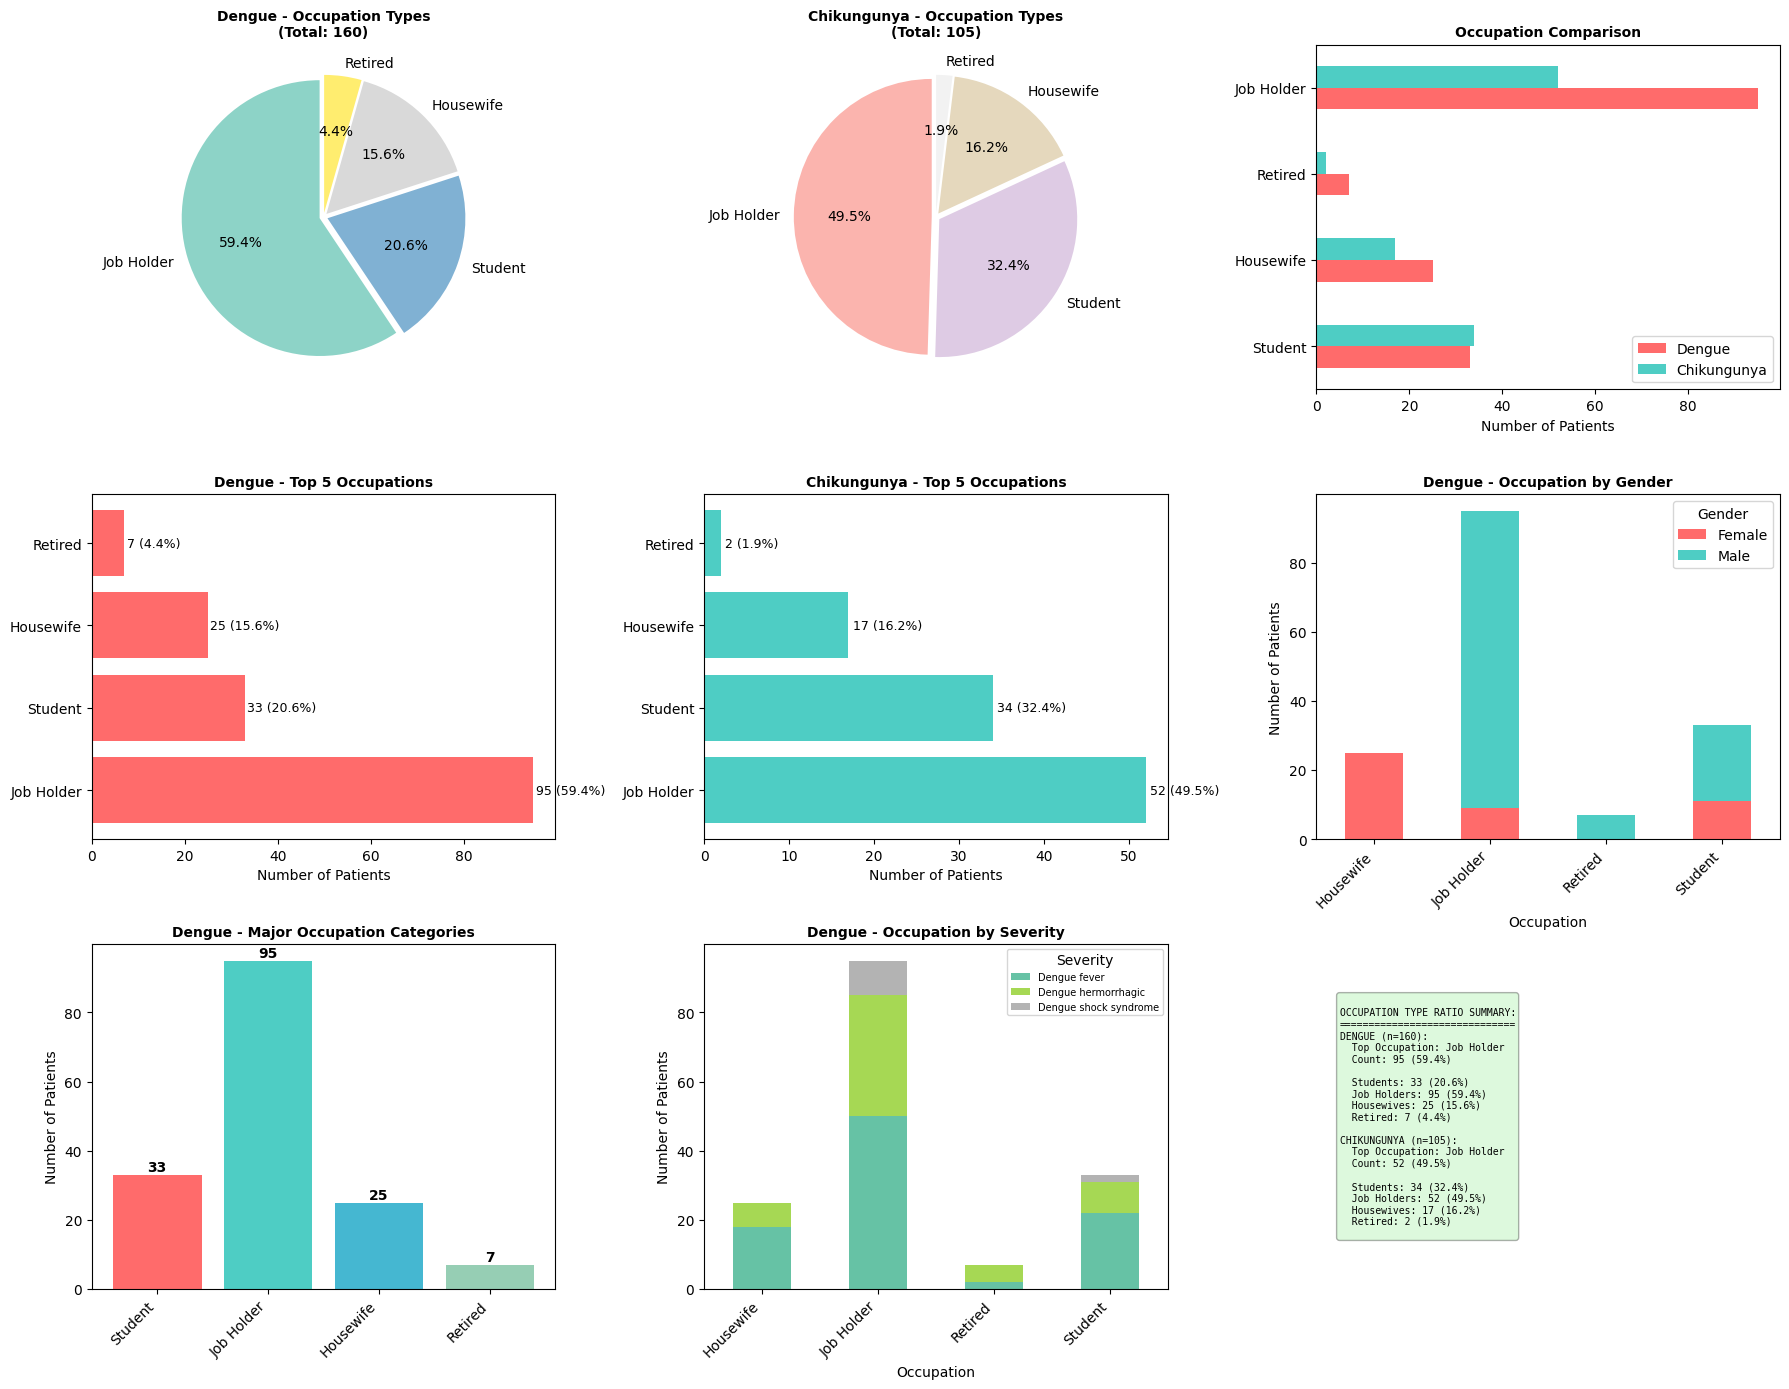


--------------------------------------------------
OCCUPATION TYPE DETAILED BREAKDOWN
--------------------------------------------------

Occupation             Dengue   Dengue %    Chik.    Chik. %
------------------------------------------------------------
Housewife                  25      15.6%       17      16.2%
Job Holder                 95      59.4%       52      49.5%
Retired                     7       4.4%        2       1.9%
Student                    33      20.6%       34      32.4%


In [ ]:
# =============================================================================
# 3. OCCUPATION TYPE ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("3. OCCUPATION TYPE ANALYSIS")
print("="*70)

# Find occupation column
occupation_col = 'Occupation Type'

# Get counts
occupation_dengue = df_dengue[occupation_col].value_counts()
occupation_chik = df_chik[occupation_col].value_counts()

print(f"\nDengue - Occupation Types:")
for idx, val in occupation_dengue.items():
    print(f"  {idx}: {val} ({val/total_dengue*100:.1f}%)")

print(f"\nChikungunya - Occupation Types:")
for idx, val in occupation_chik.items():
    print(f"  {idx}: {val} ({val/total_chik*100:.1f}%)")

plt.figure(figsize=(18, 14))

# Subplot 1: Dengue Occupation Pie
plt.subplot(3, 3, 1)
colors_occ = plt.cm.Set3(np.linspace(0, 1, len(occupation_dengue)))
plt.pie(occupation_dengue.values, labels=occupation_dengue.index, autopct='%1.1f%%',
        colors=colors_occ, startangle=90, explode=[0.03]*len(occupation_dengue))
plt.title(f'Dengue - Occupation Types\n(Total: {total_dengue})', fontsize=10, fontweight='bold')

# Subplot 2: Chikungunya Occupation Pie
plt.subplot(3, 3, 2)
colors_occ2 = plt.cm.Pastel1(np.linspace(0, 1, len(occupation_chik)))
plt.pie(occupation_chik.values, labels=occupation_chik.index, autopct='%1.1f%%',
        colors=colors_occ2, startangle=90, explode=[0.03]*len(occupation_chik))
plt.title(f'Chikungunya - Occupation Types\n(Total: {total_chik})', fontsize=10, fontweight='bold')

# Subplot 3: Occupation Comparison Bar
plt.subplot(3, 3, 3)
# Get top occupations across both
all_occupations = list(set(list(occupation_dengue.head(8).index) + list(occupation_chik.head(8).index)))
occ_comparison = pd.DataFrame({
    'Dengue': [occupation_dengue.get(occ, 0) for occ in all_occupations],
    'Chikungunya': [occupation_chik.get(occ, 0) for occ in all_occupations]
}, index=all_occupations)

occ_comparison.plot(kind='barh', color=['#FF6B6B', '#4ECDC4'], ax=plt.gca())
plt.title('Occupation Comparison', fontsize=10, fontweight='bold')
plt.xlabel('Number of Patients')
plt.legend()

# Subplot 4: Top 5 Dengue Occupations
plt.subplot(3, 3, 4)
top5_dengue = occupation_dengue.head(5)
bars = plt.barh(range(len(top5_dengue)), top5_dengue.values, color='#FF6B6B')
plt.yticks(range(len(top5_dengue)), top5_dengue.index)
plt.title('Dengue - Top 5 Occupations', fontsize=10, fontweight='bold')
plt.xlabel('Number of Patients')
for bar, val in zip(bars, top5_dengue.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/total_dengue*100:.1f}%)', va='center', fontsize=9)

# Subplot 5: Top 5 Chikungunya Occupations
plt.subplot(3, 3, 5)
top5_chik = occupation_chik.head(5)
bars = plt.barh(range(len(top5_chik)), top5_chik.values, color='#4ECDC4')
plt.yticks(range(len(top5_chik)), top5_chik.index)
plt.title('Chikungunya - Top 5 Occupations', fontsize=10, fontweight='bold')
plt.xlabel('Number of Patients')
for bar, val in zip(bars, top5_chik.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/total_chik*100:.1f}%)', va='center', fontsize=9)

# Subplot 6: Occupation by Gender (Dengue)
plt.subplot(3, 3, 6)
# Get top 5 occupations
top5_occ = df_dengue[occupation_col].value_counts().head(5).index
# Filter dataframe for only top 5 occupations
df_top5 = df_dengue[df_dengue[occupation_col].isin(top5_occ)]
occ_gender_dengue = pd.crosstab(df_top5[occupation_col], df_top5['Gender'])
if len(occ_gender_dengue) > 0:
    occ_gender_dengue.plot(kind='bar', stacked=True, ax=plt.gca(),
                          color=['#FF6B6B', '#4ECDC4'])
    plt.title('Dengue - Occupation by Gender', fontsize=10, fontweight='bold')
    plt.xlabel('Occupation')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Gender')

# Subplot 7: Occupation by Education (Dengue)
plt.subplot(3, 3, 7)
occ_edu_dengue = pd.crosstab(df_dengue[occupation_col].isin(['Student', 'Job Holder', 'Housewife']),
                              df_dengue['Educational level/Literacy'])
# Simplified view
occ_categories = ['Student', 'Job Holder', 'Housewife', 'Retired']
occ_edu_data = {}
for occ in occ_categories:
    subset = df_dengue[df_dengue[occupation_col] == occ]
    occ_edu_data[occ] = len(subset)

bars = plt.bar(occ_categories, [occ_edu_data.get(occ, 0) for occ in occ_categories],
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Dengue - Major Occupation Categories', fontsize=10, fontweight='bold')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, [occ_edu_data.get(occ, 0) for occ in occ_categories]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')

# Subplot 8: Occupation by Severity (Dengue)
plt.subplot(3, 3, 8)
# Get top 5 occupations
top5_occ = df_dengue[occupation_col].value_counts().head(5).index
# Filter dataframe for only top 5 occupations
df_top5 = df_dengue[df_dengue[occupation_col].isin(top5_occ)]
occ_severity = pd.crosstab(df_top5[occupation_col], df_top5['Severity Classification'])
if len(occ_severity) > 0:
    occ_severity.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set2')
    plt.title('Dengue - Occupation by Severity', fontsize=10, fontweight='bold')
    plt.xlabel('Occupation')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Severity', fontsize=7)

# Subplot 9: Summary
plt.subplot(3, 3, 9)
plt.axis('off')
occ_summary = f"""
OCCUPATION TYPE RATIO SUMMARY:
==============================
DENGUE (n={total_dengue}):
  Top Occupation: {occupation_dengue.index[0]}
  Count: {occupation_dengue.values[0]} ({occupation_dengue.values[0]/total_dengue*100:.1f}%)

  Students: {occupation_dengue.get('Student', 0)} ({(occupation_dengue.get('Student', 0)/total_dengue*100):.1f}%)
  Job Holders: {occupation_dengue.get('Job Holder', 0)} ({(occupation_dengue.get('Job Holder', 0)/total_dengue*100):.1f}%)
  Housewives: {occupation_dengue.get('Housewife', 0)} ({(occupation_dengue.get('Housewife', 0)/total_dengue*100):.1f}%)
  Retired: {occupation_dengue.get('Retired', 0)} ({(occupation_dengue.get('Retired', 0)/total_dengue*100):.1f}%)

CHIKUNGUNYA (n={total_chik}):
  Top Occupation: {occupation_chik.index[0]}
  Count: {occupation_chik.values[0]} ({occupation_chik.values[0]/total_chik*100:.1f}%)

  Students: {occupation_chik.get('Student', 0)} ({(occupation_chik.get('Student', 0)/total_chik*100):.1f}%)
  Job Holders: {occupation_chik.get('Job Holder', 0)} ({(occupation_chik.get('Job Holder', 0)/total_chik*100):.1f}%)
  Housewives: {occupation_chik.get('Housewife', 0)} ({(occupation_chik.get('Housewife', 0)/total_chik*100):.1f}%)
  Retired: {occupation_chik.get('Retired', 0)} ({(occupation_chik.get('Retired', 0)/total_chik*100):.1f}%)
"""
plt.text(0.05, 0.5, occ_summary, fontsize=7, family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3),
         verticalalignment='center')

plt.tight_layout()
plt.show()

# Print detailed occupation breakdown
print("\n" + "-"*50)
print("OCCUPATION TYPE DETAILED BREAKDOWN")
print("-"*50)
print(f"\n{'Occupation':<20} {'Dengue':>8} {'Dengue %':>10} {'Chik.':>8} {'Chik. %':>10}")
print("-"*60)
all_occs = sorted(set(list(occupation_dengue.index) + list(occupation_chik.index)))
for occ in all_occs:
    d_count = occupation_dengue.get(occ, 0)
    c_count = occupation_chik.get(occ, 0)
    d_pct = (d_count/total_dengue*100) if total_dengue > 0 else 0
    c_pct = (c_count/total_chik*100) if total_chik > 0 else 0
    print(f"{occ:<20} {d_count:>8} {d_pct:>9.1f}% {c_count:>8} {c_pct:>9.1f}%")